<a href="https://colab.research.google.com/github/NahomKidane/ai301-labs/blob/main/m03-embeddings/guided-labs/AI301_Guided_Lab_Part3_Concept_Scale_and_the_Limits_of_Static_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guided Lab, Part 3: What Scale Buys, and Where Static Embeddings Fail

**AI 301: Natural Language Processing and Conversational AI**

**Module 3 · Embeddings**

> Save a copy before you start. File, then Save a copy in Drive, and work in your copy.
>
> Leave the runtime on CPU. Training here runs on the CPU and a GPU does not speed it up.
>
> Section 0 installs gensim, which Colab does not ship.
>
> One download. Section 1 fetches `text8`, a 31.6 MB text corpus, cached for the rest of the session.
> No model weights are downloaded and nothing here generates text.

Follow the course AI use policy. This is a self-study lab. Nothing is submitted and nothing is graded.

**Name:**

---

Part 2 trained word2vec on eight sentences and it worked. This part asks two questions about that
result.

> ## What does more text buy, and what can this whole family of methods never do?

**Check Your Understanding** boxes appear throughout. Answer first, then click to reveal. They are
not graded.

# 0. Setup

gensim is not part of the Colab image, so install it first. If the import below fails, choose
Runtime, then Restart session, and run both cells again.

In [ ]:
!pip install -q gensim

Part 2 wrote two helpers, a similarity table and a t-SNE plot. This notebook runs on its own, so both
are repeated here unchanged along with the imports they need. Run this cell before anything else.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# from Part 2 section 4.1, cosine similarity for a list of word pairs
def similarity_table(model, pairs):
    rows = []
    for a, b in pairs:
        score = model.wv.similarity(a, b)
        rows.append({"word 1": a, "word 2": b, "similarity": round(float(score), 3)})
    return pd.DataFrame(rows)

# from Part 2 section 5.1, the whole space squeezed into two dimensions
def plot_words(model, groups, colours, title, perplexity):
    # collect the words that this model actually knows, and remember each one's group
    words = []
    group_of = {}
    for group in groups:
        for word in groups[group]:
            if word in model.wv:
                words.append(word)
                group_of[word] = group

    # stack their vectors into one array
    vectors = []
    for word in words:
        vectors.append(model.wv[word])
    vectors = np.array(vectors)

    # squeeze the vectors down to two dimensions for plotting
    reducer = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca")
    points = reducer.fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    for i in range(len(words)):
        group = group_of[words[i]]
        plt.scatter(points[i, 0], points[i, 1], color=colours[group], s=60)
        plt.annotate(words[i], (points[i, 0], points[i, 1]), fontsize=9,
                     xytext=(4, 4), textcoords="offset points")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("helpers ready")

# 1. What two million tokens change

The toy model in Part 2 learned eight sentences. To learn anything about English it needs to read
English. Same algorithm, same code, more text.

`text8` is the first hundred million characters of a 2006 English Wikipedia dump, cleaned down to
lowercase letters and spaces. gensim can fetch it.

> `text8` is a 31.6 MB download and is cached for the rest of the session. Dataset entry:
> https://github.com/piskvorky/gensim-data. Read it to see how the corpus was cleaned, since that
> cleaning is what the vectors end up describing.

In [ ]:
import gensim.downloader as api
from gensim.models.word2vec import Text8Corpus

path = api.load("text8", return_path=True)

# text8 arrives as one long stream, chopped into chunks of 10000 tokens
sentences = []
count = 0
for sentence in Text8Corpus(path):
    sentences.append(sentence)
    count = count + 1
    # stop at 200 chunks to keep training under a minute
    if count == 200:
        break

total = 0
for s in sentences:
    total = total + len(s)

print("chunks:", len(sentences))
print("tokens:", total)

Two million tokens against the sixty in Part 2.

In [ ]:
big = Word2Vec(
    sentences,
    vector_size=100,   # ten times the toy model
    window=5,
    min_count=5,       # drop words seen fewer than five times
    sg=1,
    seed=123,
    workers=1,
    negative=5,
    epochs=5,          # five is plenty at this size
)

print("vocabulary size:", len(big.wv.index_to_key))

This takes about half a minute.

### What this shows

Five epochs, not five thousand. A larger corpus needs fewer passes, because each pass already contains
far more gradient updates.

`min_count=5` is also doing real work now. Two million tokens contain a long tail of words seen once,
and a vector trained on one occurrence is noise. Dropping them leaves about twenty two thousand words
worth keeping.

In [ ]:
pairs = [
    ("king", "queen"),
    ("king", "man"),
    ("dog", "cat"),
    ("dog", "physics"),
    ("blue", "red"),
    ("blue", "dog"),
    ("paris", "france"),
    ("paris", "dog"),
]

display(similarity_table(big, pairs))

### What this shows

None of these words existed in the toy vocabulary. The model can answer for them because it read two
million tokens of English rather than sixty.

`king` with `man` at 0.334 is the interesting one. They are related in meaning and they do not appear
in the same contexts. In this corpus `king` sits with `castile`, `macedon` and `aragon`, historical
kingdoms; `man` sits with `woman`, `mortal` and `beast`. word2vec measures contextual company, not
semantic relatedness, and here you can see the difference.

In [ ]:
for word in ["king", "dog", "blue", "paris"]:
    neighbours = []
    for neighbour, score in big.wv.most_similar(word, topn=5):
        neighbours.append(neighbour)
    print(word, "->", neighbours)

### What this shows

`blue` gives colours. `paris` gives other European cities and people connected to Paris. `king` gives
Castile, Macedon and Aragon, which are specific historical kingdoms rather than a general sense of
royalty.

That last one is the corpus showing through. This is Wikipedia, so `king` mostly occurs in articles
about particular monarchs. Train on cooking forums and `king` would neighbour something else entirely.
The vectors describe the corpus, not the language.

> **Check Your Understanding**
>
> A hiring system embeds resumes with vectors trained on twenty years of company documents. What does the paragraph above predict about that system?

<details>
<summary>Show answer</summary>

It will reproduce whatever associations are in those twenty years of documents, including the ones nobody wants reproduced. The vectors have no way to tell a pattern that reflects the world from a pattern that reflects the corpus. This is why the source of the training text is part of the model's behaviour rather than a detail about it.

</details>

## 1.1 · The same plot, the bigger model

The same `plot_words` from section 0, a different model and a different set of words.

The four groups here are chosen the same way, by hand.

In [ ]:
BIG_GROUPS = {
    "colours": ["blue", "red", "green", "yellow", "black", "white"],
    "animals": ["dog", "cat", "horse", "bird", "fish", "cow"],
    "countries": ["france", "germany", "italy", "spain", "japan", "india"],
    "science": ["physics", "chemistry", "biology", "mathematics", "geology", "astronomy"],
}
BIG_COLOURS = {
    "colours": "steelblue",
    "animals": "tomato",
    "countries": "seagreen",
    "science": "darkorange",
}

plot_words(big, BIG_GROUPS, BIG_COLOURS, "word2vec, two million tokens", 5)

### What this shows

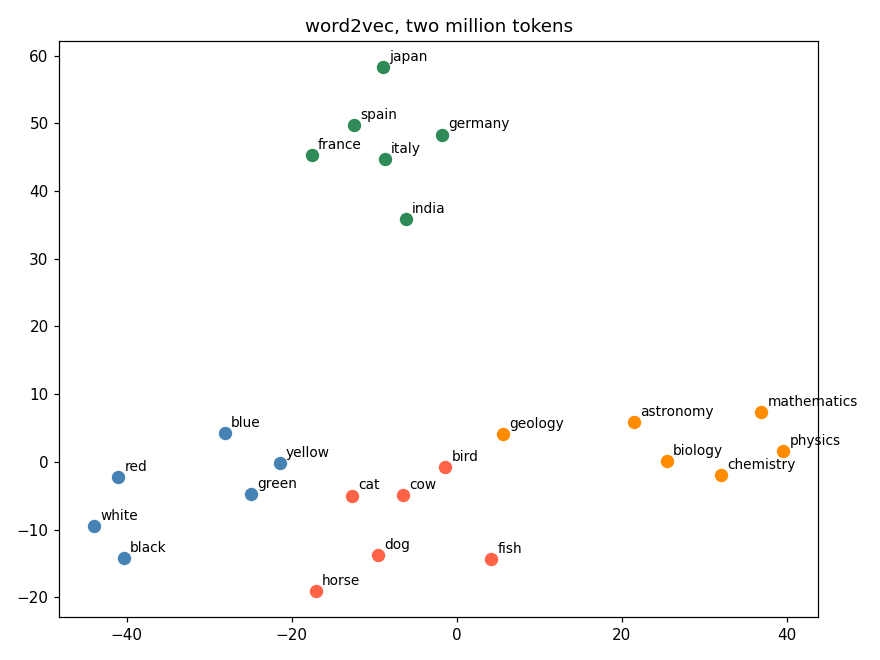

Four groups, four regions, no overlap, and this time the groups were not planted in the corpus.
Nobody wrote two million tokens of Wikipedia with these four categories in mind.

Look also at where the groups sit relative to each other. Colours and animals are neighbours, and both
sit away from countries and sciences.

# 2. The analogy

The result word2vec became famous for. Take the vector for `king`, subtract `man`, add `woman`, and
look for the nearest word to what is left.

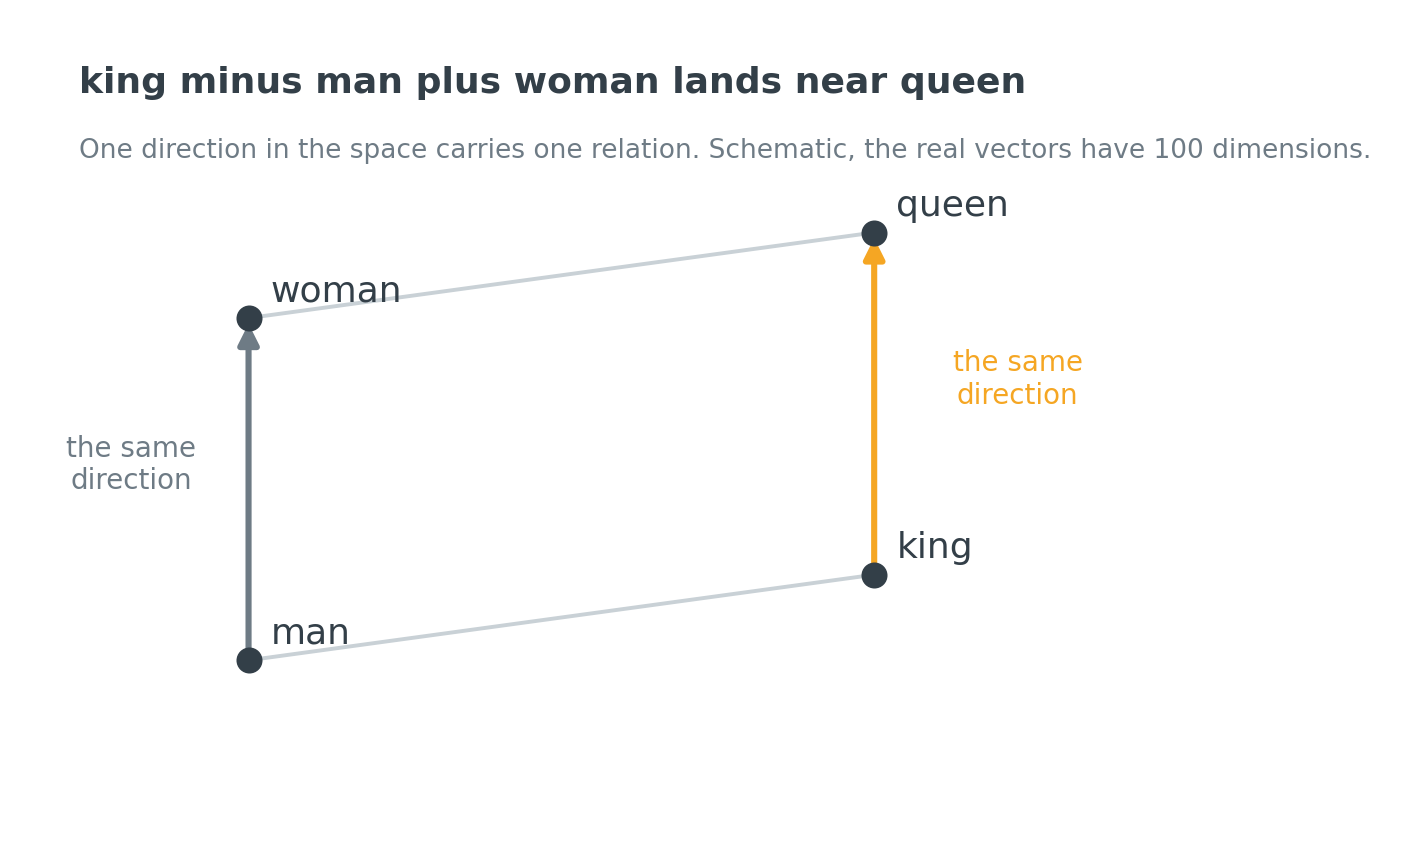

The claim the picture makes is that one direction in the space carries one relation. If the step from
`man` to `woman` is the same step as the one from `king` to `queen`, then adding that step to `king`
should land on `queen`. Whether it does is what the cell below measures.

In [ ]:
result = big.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
for word, score in result:
    print(word, round(float(score), 3))

### What this shows

`queen` is in the list, at rank five. The published demonstrations put it at rank one, and they used
the full `text8` corpus or larger, roughly seventeen million tokens against your two million.
Everything above `queen` here is royalty adjacent, so the direction is right and the resolution is not.

Two things to take from this. The arithmetic works, in the sense that a consistent direction in the
space really does correspond to something. And the famous version of the result is a best case on a
large corpus with a hand picked pair, not a general property you can lean on.

# 3. Where static embeddings fail

Everything below uses the `big` model you trained in section 1. Two million tokens is small, so some
of what follows is the corpus being thin and some of it is the method. The three failures here are
the method, and they do not improve with more text.

## 3.1 · One word, one vector

`most_similar` on a handful of words that mean more than one thing.

In [ ]:
for word in ["bank", "apple", "spring", "python"]:
    neighbours = []
    for neighbour, score in big.wv.most_similar(word, topn=6):
        neighbours.append(neighbour)
    print(word, "->", neighbours)

### What this shows

Each of these words has more than one meaning, and each came back with one.

`bank` returns `luanda`, `landlocked`, `bombay`, `caribbean`, geography rather than finance, because
in this slice of Wikipedia the river and coastline sense dominates. `apple` returns `macintosh`,
`iic`, `atari`, `mac`, the computer company with no fruit anywhere. `spring` returns `autumn`,
`summer`, `solstice`, the season and neither the coil nor the water source.

There is no bug. The model holds one row for the string `bank`. Every occurrence in two million
tokens updated that same row, and the sense that occurred more often won. The losing sense is not
stored somewhere else. It is not stored at all.

`python` is the control. It comes back as noise, `richer`, `termite`, `dove`, because it appears too
few times here to have a usable vector at all. That is a corpus problem and more text fixes it. The
`bank` result is not, and more text does not.

A search system built on these vectors returns river pages to someone asking about a bank loan, and
it does it confidently.

## 3.2 · Opposites look alike

Words that mean the opposite of each other appear in almost identical contexts. You buy a house and
you sell a house. Prices increase and prices decrease. Distributional similarity cannot tell those
apart.

In [ ]:
opposites = [
    ("up", "down"),
    ("buy", "sell"),
    ("increase", "decrease"),
    ("always", "never"),
    ("good", "bad"),
    ("hot", "cold"),
]

rows = []
for a, b in opposites:
    rows.append({"word 1": a, "word 2": b,
                 "similarity": round(float(big.wv.similarity(a, b)), 3)})

display(pd.DataFrame(rows))

print()
print("for comparison")
for a, b in [("good", "excellent"), ("good", "table"), ("hot", "warm"), ("hot", "table")]:
    print(" ", a, b, round(float(big.wv.similarity(a, b)), 3))

### What this shows

`buy` and `sell` score 0.838, `increase` and `decrease` 0.779, `good` and `bad` 0.72. Now read the
comparison line: `good` and `excellent`, a synonym pair, score 0.515. The antonym scores higher than
the synonym.

The one pair that behaves is `hot` and `warm` at 0.735 against `hot` and `cold` at 0.643, and it is
worth asking why that one came out right when the others did not.

Cosine similarity here measures relatedness, not agreement. Anything that depends on polarity,
sentiment above all, cannot be read off these numbers.

## 3.3 · Word order and negation vanish

Part 1 built a sentence vector by averaging the token vectors, and averaging throws away order. Here
is the size of that problem.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def sentence_vector(text, vectors):
    total = np.zeros(vectors.vector_size)
    n = 0
    for word in text.lower().split():
        if word in vectors:
            total = total + vectors[word]
            n = n + 1
    if n > 0:
        total = total / n
    return total

pairs = [
    ("the film was good and not boring", "the film was boring and not good"),
    ("the dog bit the man", "the man bit the dog"),
    ("i loved it", "i did not love it"),
]

for a, b in pairs:
    va = sentence_vector(a, big.wv)
    vb = sentence_vector(b, big.wv)
    score = cosine_similarity([va], [vb])[0][0]
    print(round(float(score), 3), "|", a, "||", b)

### What this shows

The first two pairs score exactly 1.0. Not close to 1.0, exactly 1.0, because the two sentences
contain the same words and addition does not care about order. One review is positive and the other is
negative, and the representation cannot tell them apart at all.

The third pair scores 0.868 because `did` and `not` were added, and those two words move the average
barely at all. The word that reverses the meaning of the sentence is one small vector among five.

This is not a flaw in word2vec. It is what happens when a sentence is represented as a bag of its
words.

> **Check Your Understanding**
>
> A sentiment classifier is built by averaging word vectors for each review and training a classifier on the averages. Which reviews will it get wrong?

<details>
<summary>Show answer</summary>

Anything where the meaning depends on order or negation. Sarcasm, contrast ("the acting was great, the plot was not"), and any explicit negation. It can still do well on average, because most reviews signal their polarity through word choice alone, which is why this approach was used for years. It fails on exactly the cases a person would find easy.

</details>

## 3.4 · What every failure has in common

| What fails | Why |
|---|---|
| `bank`, `apple` and `spring` return one sense | one vector per word, so senses are averaged into one point |
| `buy` and `sell` score 0.838, above `good` and `excellent` | opposites occur in the same contexts, and context is all the model sees |
| Two opposite reviews score 1.0 | a document is the mean of its words, and a mean has no order |

The first two are the same limitation. A word gets its vector before any sentence is read, so nothing
about a particular use can change it. That is what **static** means, and it is the word that separates
every model in Parts 2 and 3 from the one in Part 1.

Part 1 already showed the alternative. BERT reads the whole sentence before assigning a vector to any
word in it, which is why `bank` came back as two different vectors there and as one here.

## Optional extensions

**Optional Extension A · More text.** Change `count == 200` in section 1 to `count == 1000`, rerun the
training cell and the analogy, and see where `queen` lands. Training takes roughly five times as long.

**Optional Extension B · CBOW against skip-gram.** Retrain the `big` model with `sg=0` and compare the
same eight similarity pairs. CBOW trains faster on the same corpus. Check whether the pairs involving
rarer words move more than the pairs involving common ones.

**Optional Extension C · A different corpus.** `gensim.downloader` also carries `20-newsgroups` and
`fake-news`. Train on one of them and look at the neighbours of `king`, `blue` and `paris` again. The
neighbours should tell you which corpus you trained on.

**Optional Extension D · Your own words.** Put words from your own field into `BIG_GROUPS` in section
1.1 and replot. Words the model does not know are skipped, so check `word in big.wv` first and see how
much of your field's vocabulary a 2006 Wikipedia dump actually covers.

## Check yourself

- Why does a larger corpus need fewer passes than eight sentences did?
- What is `min_count=5` doing on a two million token corpus, and why was it pointless on sixty?
- Why does `king` neighbour `castile` and `macedon` rather than `royal` and `crown`?
- The analogy put `queen` at rank five rather than rank one. What would move it up?
- Why does `bank` come back as geography and never as finance?
- Why do `buy` and `sell` score higher than `good` and `excellent`?
- What does averaging word vectors into a sentence vector discard, and what does it keep?
- What single property causes all three failures in section 3?

## Summary

Two million tokens of Wikipedia give a vocabulary of about twenty two thousand words and vectors that
separate colours, animals, countries and sciences without anyone planting those categories. The
analogy works in the sense that a consistent direction in the space corresponds to a relation, and the
famous version of it is a best case rather than a general property. What the vectors describe is the
corpus, which is why `king` neighbours `castile`.

The limits are one limit. A static embedding assigns a word its vector before any sentence is read.
So a word with two senses gets one blended vector, opposites that share contexts score as close as
synonyms, and two sentences built from the same words score identical no matter what they say. Part 1
showed what removes that limit, a model that reads the sentence first.

## References

**What this notebook used**

- [gensim `Word2Vec`](https://radimrehurek.com/gensim/models/word2vec.html). Every argument in the
  training cell, and `most_similar`, which takes `positive` and `negative` lists for the analogy.
- [gensim-data](https://github.com/piskvorky/gensim-data). The `text8` entry, where the corpus comes
  from and how it was cleaned.
- [`Text8Corpus`](https://radimrehurek.com/gensim/models/word2vec.html#gensim.models.word2vec.Text8Corpus).
  Why the corpus arrives as chunks of 10,000 tokens rather than sentences.
- [scikit-learn t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).
  What `perplexity` does and why the axes carry no meaning.

**Reading**

- Alammar and Grootendorst, *Hands-On Large Language Models*, chapter 2, the embeddings half.
  [UT Libraries](https://utk.primo.exlibrisgroup.com/permalink/01UTN_KNOXVILLE/bcmt7h/alma9926674015102311).
- [Jurafsky and Martin, chapter 5, Embeddings](https://web.stanford.edu/~jurafsky/slp3/5.pdf), the
  sections on cosine similarity and on what the analogy does and does not show.
- [Mikolov et al. (2013), Distributed Representations of Words and Phrases](https://arxiv.org/abs/1310.4546).
  The analogy results this section reproduces at a smaller scale.